# ODE vs Discrete Forward Simulation Benchmarking
This notebook compares the mathematical accuracy and computational runtime of the High-Resolution ODE solver (`torchdiffeq.odeint`) against the highly-optimized native `ExperimentRunner`.

In [8]:
import sys
import time
sys.path.append("../..")

import torch
import matplotlib.pyplot as plt
import numpy as np
from torchdiffeq import odeint
from src.config.schemas import ExperimentConfig, GameConfig, DynamicConfig, ExecutionConfig
from src.engine.runner import ExperimentRunner
from src.engine.statistics import load_experiment_stats
from src.dynamics.continuous import OMWUContinuous

plt.style.use('ggplot')

# Use CUDA if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


Using device: cuda


In [13]:
from engine.optimizer import CMAESGameOptimizer
session_id = '8a3c6353'
saved_data = CMAESGameOptimizer.load_results(session_id, '../outputs')
saved_data["payoffs"]

[tensor([[-0.2181,  0.0133],
         [-0.2457,  0.0216]]),
 tensor([[-0.0509, -0.0178],
         [ 0.4770,  0.1116]])]

In [17]:
# ==========================================
# 1. Forward Discrete Simulation Benchmarking
# ==========================================
total_steps = 50000

config = ExperimentConfig(
    name="notebook_compare",
    game=GameConfig(generator="custom", utility_range=(-1.0, 1.0), payoffs=saved_data["payoffs"]),
    dynamic=DynamicConfig(
        algorithm="omwu",
    ),
    execution=ExecutionConfig(total_steps=total_steps, device="auto",
        dtype="float64", # Can be float64 for higher precision
        steps_per_call=200, seed=42, compile=True)
)

runner = ExperimentRunner(config=config)

# Benchmark native runner
torch.cuda.synchronize() if torch.cuda.is_available() else None
t0_discrete = time.time()

summary = runner.run(target_steps=total_steps)

torch.cuda.synchronize() if torch.cuda.is_available() else None
t1_discrete = time.time()
discrete_time = t1_discrete - t0_discrete

# Load exact regrets
stats_data = load_experiment_stats(output_dir=summary["output_dir"], session_id=summary["session_id"])
steps = stats_data["steps"].numpy()
discrete_regret_p1 = stats_data["cum_regrets"].numpy()[:, 0]  # Player 1
discrete_regret_p2 = stats_data["cum_regrets"].numpy()[:, 1]  # Player 2

# Extract the randomly generated game matrices
payoffs = runner.game.get_payoff_tensors()
U1 = payoffs[0].squeeze(0) if payoffs[0].dim() == 3 else payoffs[0]
U2 = payoffs[1].squeeze(0) if payoffs[1].dim() == 3 else payoffs[1]
A1, A2 = U1.shape


[09/10/26 14:15:53] INFO     Inferred OMWU empirical eta = 0.062500 (1 / (8 * max(A)))

[09/10/26 14:15:53] INFO     Enabling PyTorch JIT compilation via torch.compile(backend='cudagraphs')...

                    INFO     Starting simulation 'notebook_compare' [Session: f5a0bebf-4293-489d-b522-bd4ea2b1206f]
                             on device 'cuda' for T=50000 steps.

Output()

[09/10/26 14:16:00] INFO     Simulation completed cleanly! Final Max Avg Regret: 0.000221. Stats session ID        
                             'f5a0bebf-4293-489d-b522-bd4ea2b1206f' in 'outputs'

In [18]:
# ==========================================
# 2. Forward Continuous ODE Benchmarking
# ==========================================
# We must use the exact empirical learning rate that the runner used
emp_eta = runner.dynamic.eta

if isinstance(emp_eta, torch.Tensor):
    emp_eta = emp_eta.item()

dyn = OMWUContinuous([U1, U2], emp_eta)
import sys
backend = "cudagraphs" if (sys.platform == "win32" and device.type == "cuda") else "inductor"
dyn_compiled = torch.compile(dyn, backend=backend)
state0 = dyn.get_initial_state(device=device)
T = total_steps * emp_eta
t = torch.linspace(0, T, total_steps, device=device)

torch.cuda.synchronize() if torch.cuda.is_available() else None
t0_ode = time.time()

# Run ODE forward pass
class ClonedODE(torch.nn.Module):
    def __init__(self, compiled_dyn):
        super().__init__()
        self.compiled_dyn = compiled_dyn
    def forward(self, t, y):
        if hasattr(torch.compiler, "cudagraph_mark_step_begin"):
            torch.compiler.cudagraph_mark_step_begin()
        return self.compiled_dyn(t, y).clone()

with torch.no_grad():
    states = odeint(ClonedODE(dyn_compiled), state0, t, method='euler', options={'step_size': emp_eta})

torch.cuda.synchronize() if torch.cuda.is_available() else None
t1_ode = time.time()
ode_time = t1_ode - t0_ode

# Extract continuous regret trajectory
unpacked = dyn.unpack_states(states, eta=emp_eta)
continuous_regret_p1 = np.max(unpacked["regrets"][0].cpu().numpy(), axis=-1)
continuous_regret_p2 = np.max(unpacked["regrets"][1].cpu().numpy(), axis=-1)

print(f"Native Discrete Engine Time : {discrete_time:.4f} seconds")
print(f"Continuous ODE Forward Time : {ode_time:.4f} seconds")
print(f"ODE Overhead Ratio : {ode_time / discrete_time:.2f}x slower")

Native Discrete Engine Time : 6.6469 seconds
Continuous ODE Forward Time : 258.3105 seconds
ODE Overhead Ratio : 38.86x slower


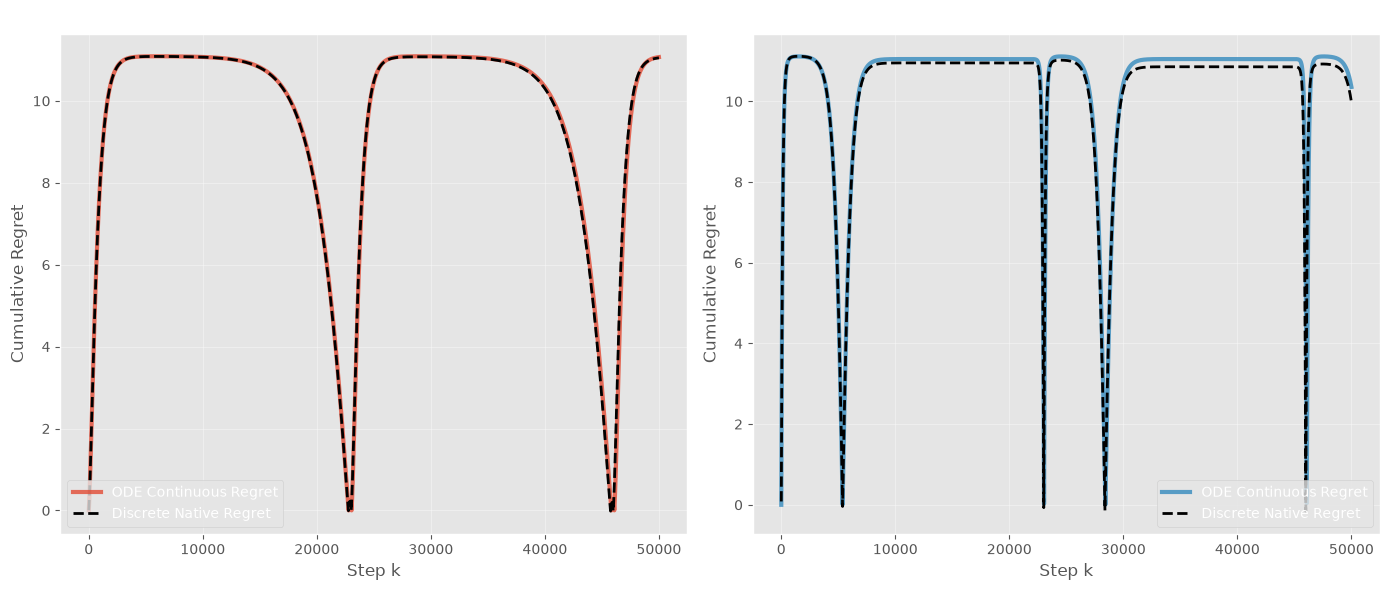

In [19]:
# Plotting
import numpy as np
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot Player 1
axs[0].plot(np.arange(1, total_steps+1), continuous_regret_p1, label="ODE Continuous Regret", linewidth=3, alpha=0.8)
axs[0].plot(steps, discrete_regret_p1, label="Discrete Native Regret", linestyle='--', linewidth=2, color='black')
axs[0].set_title("Continuous vs Discrete Regret (Player 1)")
axs[0].set_xlabel("Step k")
axs[0].set_ylabel("Cumulative Regret")
axs[0].legend()

# Plot Player 2
axs[1].plot(np.arange(1, total_steps+1), continuous_regret_p2, label="ODE Continuous Regret", linewidth=3, alpha=0.8, color='C1')
axs[1].plot(steps, discrete_regret_p2, label="Discrete Native Regret", linestyle='--', linewidth=2, color='black')
axs[1].set_title("Continuous vs Discrete Regret (Player 2)")
axs[1].set_xlabel("Step k")
axs[1].set_ylabel("Cumulative Regret")
axs[1].legend()

plt.tight_layout()
plt.show()
